MEDICAL INSURANCE COST PREDICTION PROJECT

Dataset Shape:
(1338, 7)

Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

First 5 Rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   133

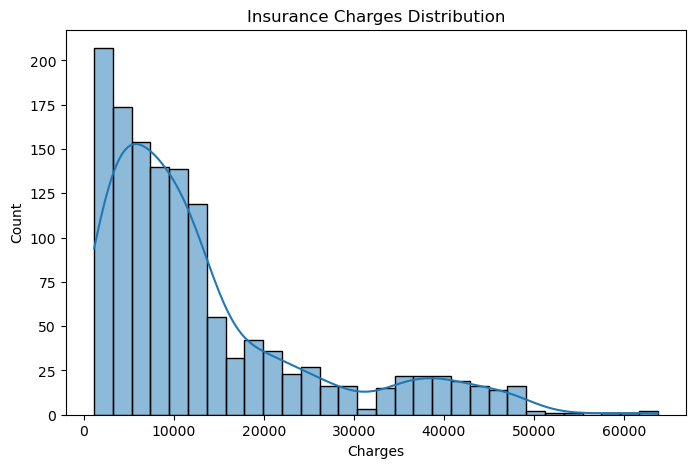

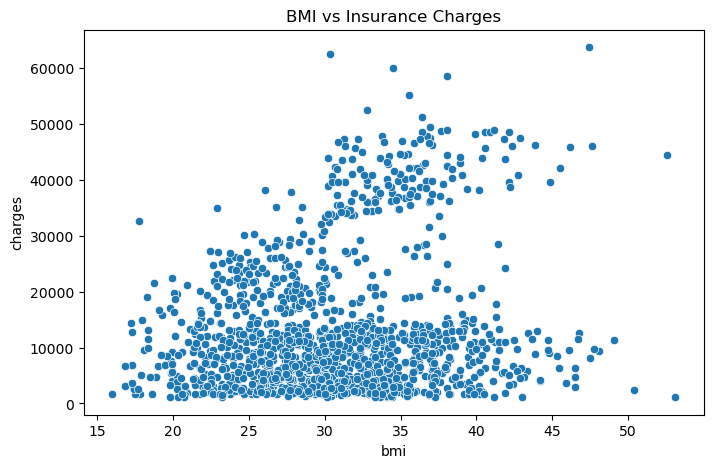

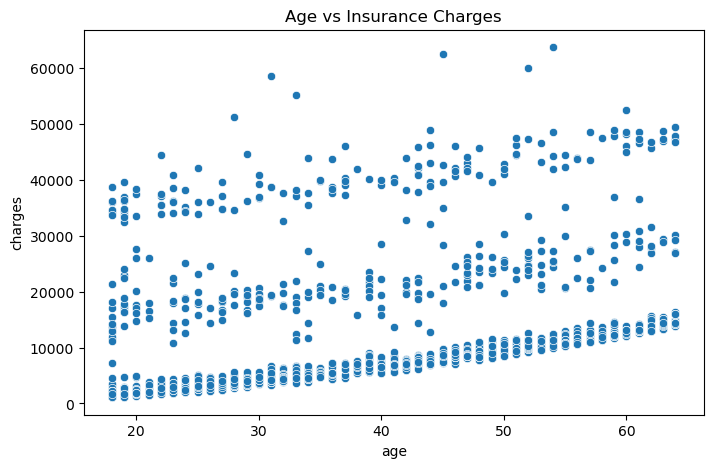

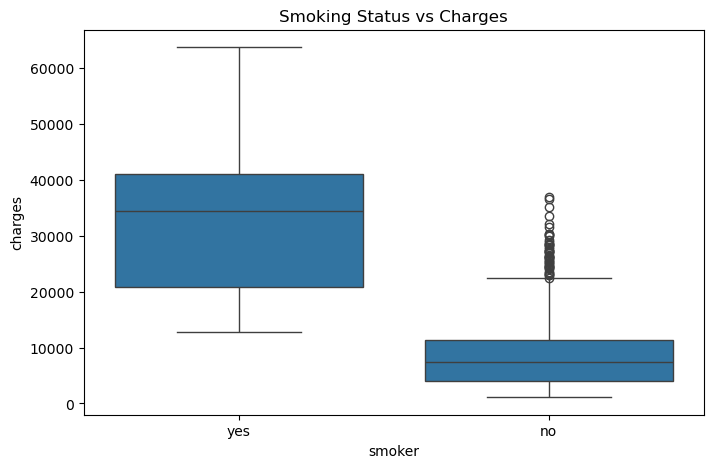

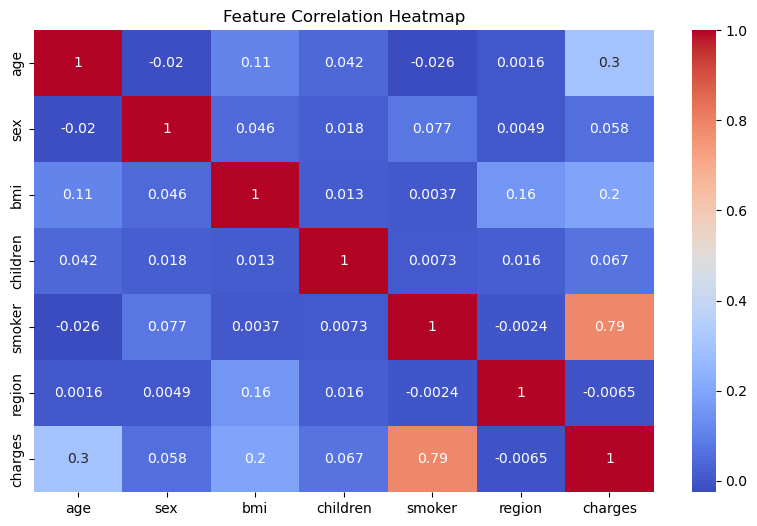


Encoded Dataset:
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

MODEL PERFORMANCE
Mean Absolute Error (MAE): 4177.05
Root Mean Squared Error (RMSE): 5956.34
R² Score: 0.8069

Sample Predictions:
      Actual Charges  Predicted Charges
900       8688.85885        8143.693884
1064      5708.86700        5737.115683
1256     11436.73815       14369.314876
298      38746.35

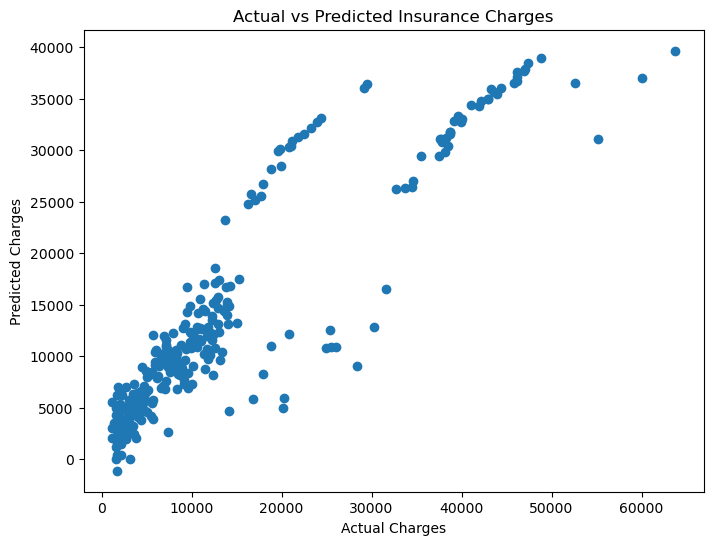


Feature Influence on Charges:
            Feature   Coefficient
4            smoker  23077.764593
3          children    533.009989
2               bmi    318.701441
0               age    248.210720
1               sex   -101.542054
5  region_northwest   -391.761455
7  region_southwest   -659.139752
6  region_southeast   -838.919616


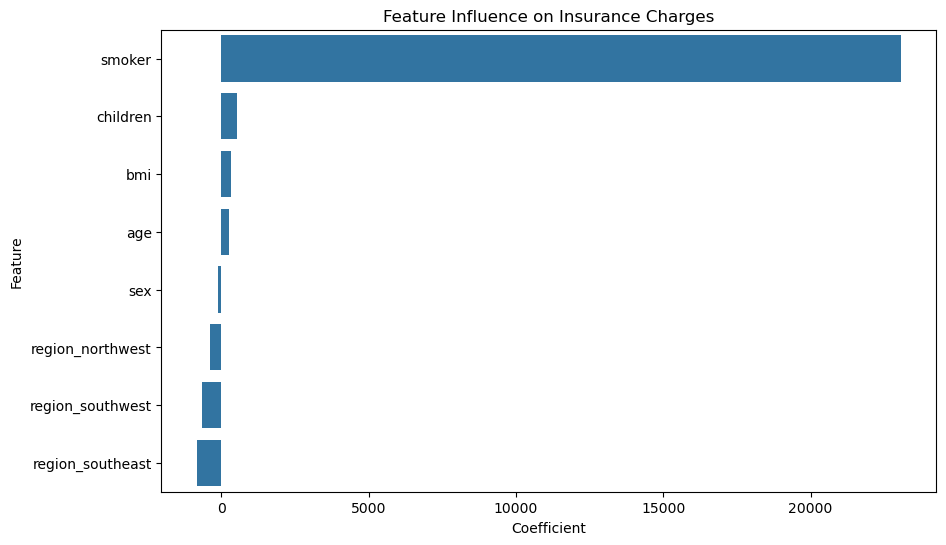


BUSINESS INSIGHTS

1. Age positively impacts insurance charges.

2. Higher BMI generally leads to higher medical costs.

3. Smoking is the strongest factor influencing charges.

4. Smokers pay significantly more than non-smokers.

5. Linear Regression successfully predicts insurance costs.

6. Insurance companies can use this model
   to estimate future claim amounts.

7. High-risk customers can be identified
   based on age, BMI, and smoking behavior.


PROJECT COMPLETED SUCCESSFULLY


In [1]:
# ==========================================================
# TASK 4: INSURANCE CLAIM AMOUNT PREDICTION
# Internship-Level Professional Solution
# ==========================================================

# ==========================
# IMPORT LIBRARIES
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================================
# LOAD DATASET
# ==========================================================

file_path = r"C:\Users\HP\OneDrive\Desktop\DS\insurance.csv"

df = pd.read_csv(file_path)

print("=" * 70)
print("MEDICAL INSURANCE COST PREDICTION PROJECT")
print("=" * 70)

# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ==========================================================
# DATA CLEANING
# ==========================================================

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove duplicates if any
df.drop_duplicates(inplace=True)

print("\nDataset Shape After Cleaning:")
print(df.shape)

# ==========================================================
# EXPLORATORY DATA ANALYSIS
# ==========================================================

# Charges Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df["charges"],
    bins=30,
    kde=True
)

plt.title("Insurance Charges Distribution")
plt.xlabel("Charges")
plt.show()

# ==========================================================
# BMI IMPACT ON CHARGES
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="bmi",
    y="charges",
    data=df
)

plt.title("BMI vs Insurance Charges")
plt.show()

# ==========================================================
# AGE IMPACT ON CHARGES
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="age",
    y="charges",
    data=df
)

plt.title("Age vs Insurance Charges")
plt.show()

# ==========================================================
# SMOKER IMPACT ON CHARGES
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x="smoker",
    y="charges",
    data=df
)

plt.title("Smoking Status vs Charges")
plt.show()

# ==========================================================
# CORRELATION ANALYSIS
# ==========================================================

# Encode temporary copy for correlation

corr_df = df.copy()

le = LabelEncoder()

corr_df["sex"] = le.fit_transform(corr_df["sex"])
corr_df["smoker"] = le.fit_transform(corr_df["smoker"])
corr_df["region"] = le.fit_transform(corr_df["region"])

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

# ==========================================================
# ENCODING CATEGORICAL FEATURES
# ==========================================================

df_encoded = df.copy()

# Label Encoding

df_encoded["sex"] = LabelEncoder().fit_transform(
    df_encoded["sex"]
)

df_encoded["smoker"] = LabelEncoder().fit_transform(
    df_encoded["smoker"]
)

# One Hot Encoding

df_encoded = pd.get_dummies(
    df_encoded,
    columns=["region"],
    drop_first=True
)

print("\nEncoded Dataset:")
print(df_encoded.head())

# ==========================================================
# FEATURES AND TARGET
# ==========================================================

X = df_encoded.drop("charges", axis=1)

y = df_encoded["charges"]

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================================
# LINEAR REGRESSION MODEL
# ==========================================================

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

# ==========================================================
# PREDICTIONS
# ==========================================================

y_pred = model.predict(X_test)

# ==========================================================
# MODEL EVALUATION
# ==========================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# ==========================================================
# ACTUAL VS PREDICTED
# ==========================================================

comparison = pd.DataFrame({
    "Actual Charges": y_test,
    "Predicted Charges": y_pred
})

print("\nSample Predictions:")
print(comparison.head(10))

# ==========================================================
# ACTUAL VS PREDICTED PLOT
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title(
    "Actual vs Predicted Insurance Charges"
)

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nFeature Influence on Charges:")
print(coefficients)

# ==========================================================
# COEFFICIENT VISUALIZATION
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Influence on Insurance Charges")
plt.show()

# ==========================================================
# BUSINESS INSIGHTS
# ==========================================================

print("\n" + "=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

print("""
1. Age positively impacts insurance charges.

2. Higher BMI generally leads to higher medical costs.

3. Smoking is the strongest factor influencing charges.

4. Smokers pay significantly more than non-smokers.

5. Linear Regression successfully predicts insurance costs.

6. Insurance companies can use this model
   to estimate future claim amounts.

7. High-risk customers can be identified
   based on age, BMI, and smoking behavior.
""")

print("\nPROJECT COMPLETED SUCCESSFULLY")